# Customer Churn Prediction using Random Forest
## End-to-End Machine Learning and Deployment Use Case

**Course:** B.Tech – Gen AI (2nd Semester)  
**Student:** Rishabh Bheda  
**Project Type:** Individual Final Project

---
## 1. Introduction

### What is Customer Churn?
Customer churn refers to the phenomenon where customers stop doing business with a company or service. In the travel industry, churn occurs when customers discontinue using travel-related services such as bookings, loyalty programs, or premium memberships. It is one of the most critical metrics for subscription-based and service-oriented businesses.

### Why is Churn Prediction Important?
Retaining an existing customer is significantly cheaper — often **5 to 10 times less expensive** — than acquiring a new one. By predicting which customers are likely to churn, businesses can:
- Proactively reach out with personalized offers
- Improve customer satisfaction and loyalty
- Reduce revenue loss and improve lifetime value
- Allocate marketing resources more efficiently

### Why Random Forest?
Random Forest is an ensemble learning algorithm that builds multiple decision trees and merges their outputs to get a more accurate and stable prediction. It is chosen for this project because:
- It handles both categorical and numerical features effectively
- It is robust to overfitting due to ensemble averaging
- It provides **feature importance scores**, helping explain predictions
- It performs excellently on tabular, structured data without extensive tuning
- It does not require feature scaling

### Project Goal
Build a complete end-to-end machine learning pipeline: from data preprocessing → model training → evaluation → Streamlit deployment.

---
## 2. Importing Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Model persistence
import joblib

# Optional: scikit-plot
try:
    import scikitplot as skplt
    SKPLT_AVAILABLE = True
except ImportError:
    SKPLT_AVAILABLE = False

print("✅ All libraries imported successfully!")
print(f"   Pandas version   : {pd.__version__}")
print(f"   NumPy version    : {np.__version__}")
print(f"   scikit-plot ready: {SKPLT_AVAILABLE}")

✅ All libraries imported successfully!
   Pandas version   : 3.0.2
   NumPy version    : 2.4.4
   scikit-plot ready: False


---
## 3. Data Loading and Exploration

In [2]:
# Load the dataset
df = pd.read_excel('Customertravel.xlsx')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(10)

Dataset loaded successfully!
Shape: 954 rows × 7 columns



,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0
5,27,Yes,High Income,1,No,Yes,1
6,34,No,Middle Income,4,Yes,Yes,0
7,34,No,Low Income,2,Yes,No,1
8,30,No,Low Income,3,No,Yes,0
9,36,Yes,High Income,1,No,No,1


In [3]:
# Summary statistics
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
df.describe(include='all')

SUMMARY STATISTICS


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
count,954.000000,954,954,954.000000,954,954,954.000000
unique,NaN,3,3,NaN,2,2,NaN
top,NaN,No,Middle Income,NaN,No,No,NaN
freq,NaN,608,409,NaN,594,576,NaN
mean,32.109015,NaN,NaN,2.437107,NaN,NaN,0.234801
std,3.337388,NaN,NaN,1.606233,NaN,NaN,0.424097
min,27.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
25%,30.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
50%,31.000000,NaN,NaN,2.000000,NaN,NaN,0.000000
75%,35.000000,NaN,NaN,4.000000,NaN,NaN,0.000000


In [4]:
# Data types and missing values
print("=" * 50)
print("DATA TYPES & MISSING VALUES")
print("=" * 50)

info_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Missing Values': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(info_df.to_string(index=False))

DATA TYPES & MISSING VALUES
                    Column Data Type  Non-Null Count  Missing Values  Missing %
                       Age     int64             954               0        0.0
             FrequentFlyer       str             954               0        0.0
         AnnualIncomeClass       str             954               0        0.0
             ServicesOpted     int64             954               0        0.0
AccountSyncedToSocialMedia       str             954               0        0.0
          BookedHotelOrNot       str             954               0        0.0
                    Target     int64             954               0        0.0


In [5]:
# Unique values per categorical column
print("=" * 50)
print("CATEGORICAL COLUMN VALUE COUNTS")
print("=" * 50)

cat_cols = df.select_dtypes(include=['object', 'str']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

print(f"\nTarget (Churn):")
print(df['Target'].value_counts())
print(f"\nChurn Rate: {df['Target'].mean()*100:.2f}%")

CATEGORICAL COLUMN VALUE COUNTS

FrequentFlyer:
FrequentFlyer
No           608
Yes          286
No Record     60
Name: count, dtype: int64

AnnualIncomeClass:
AnnualIncomeClass
Middle Income    409
Low Income       386
High Income      159
Name: count, dtype: int64

AccountSyncedToSocialMedia:
AccountSyncedToSocialMedia
No     594
Yes    360
Name: count, dtype: int64

BookedHotelOrNot:
BookedHotelOrNot
No     576
Yes    378
Name: count, dtype: int64

Target (Churn):
Target
0    730
1    224
Name: count, dtype: int64

Churn Rate: 23.48%


---
## 4. Data Cleaning and Preprocessing

In [6]:
# Work on a copy to preserve original data
df_processed = df.copy()

# ── Step 1: Handle 'No Record' values in FrequentFlyer ──
print("Before cleaning FrequentFlyer:")
print(df_processed['FrequentFlyer'].value_counts())

# Replace 'No Record' with the mode (most frequent value)
mode_val = df_processed['FrequentFlyer'].replace('No Record', pd.NA).mode()[0]
df_processed['FrequentFlyer'] = df_processed['FrequentFlyer'].replace('No Record', mode_val)

print(f"\n'No Record' replaced with mode: '{mode_val}'")
print("After cleaning:")
print(df_processed['FrequentFlyer'].value_counts())

Before cleaning FrequentFlyer:
FrequentFlyer
No           608
Yes          286
No Record     60
Name: count, dtype: int64

'No Record' replaced with mode: 'No'
After cleaning:
FrequentFlyer
No     668
Yes    286
Name: count, dtype: int64


In [7]:
# ── Step 2: Encode Categorical Features ──
le = LabelEncoder()

categorical_columns = ['FrequentFlyer', 'AnnualIncomeClass',
                        'AccountSyncedToSocialMedia', 'BookedHotelOrNot']

label_mappings = {}
for col in categorical_columns:
    df_processed[col] = le.fit_transform(df_processed[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {label_mappings[col]}")

print("\n✅ Encoding complete!")
df_processed.head()

FrequentFlyer: {'No': np.int64(0), 'Yes': np.int64(1)}
AnnualIncomeClass: {'High Income': np.int64(0), 'Low Income': np.int64(1), 'Middle Income': np.int64(2)}
AccountSyncedToSocialMedia: {'No': np.int64(0), 'Yes': np.int64(1)}
BookedHotelOrNot: {'No': np.int64(0), 'Yes': np.int64(1)}

✅ Encoding complete!


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,0,2,6,0,1,0
1,34,1,1,5,1,0,1
2,37,0,2,3,1,0,0
3,30,0,2,2,0,0,0
4,30,0,1,1,0,0,0


In [8]:
# ── Step 3: Define Features (X) and Target (y) ──
X = df_processed.drop('Target', axis=1)
y = df_processed['Target']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Feature columns: {list(X.columns)}")
print(f"\nTarget distribution:")
print(f"  Not Churned (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Churned     (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

Features shape : (954, 6)
Target shape   : (954,)
Feature columns: ['Age', 'FrequentFlyer', 'AnnualIncomeClass', 'ServicesOpted', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']

Target distribution:
  Not Churned (0): 730 (76.5%)
  Churned     (1): 224 (23.5%)


In [9]:
# ── Step 4: Train-Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Preserve class balance
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Testing set    : {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test  churn rate: {y_test.mean()*100:.2f}%")

Training set   : 763 samples
Testing set    : 191 samples

Train churn rate: 23.46%
Test  churn rate: 23.56%


---
## 5. Model Development: Random Forest Classifier

In [10]:
# ── Train the Random Forest Classifier ──
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest model trained successfully!")
print(f"   Number of trees  : {rf_model.n_estimators}")
print(f"   Number of features: {rf_model.n_features_in_}")

✅ Random Forest model trained successfully!
   Number of trees  : 100
   Number of features: 6


In [11]:
# ── Generate Predictions ──
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated!")
print(f"Sample predictions (first 10): {y_pred[:10]}")
print(f"Sample probabilities (first 5): {y_prob[:5].round(3)}")

Predictions generated!
Sample predictions (first 10): [0 1 0 0 1 0 0 0 0 1]
Sample probabilities (first 5): [0.   0.68 0.   0.01 0.99]


In [12]:
# Save the trained model for Streamlit deployment
joblib.dump(rf_model, 'model.pkl')
print("✅ Model saved as 'model.pkl' — ready for Streamlit deployment!")

✅ Model saved as 'model.pkl' — ready for Streamlit deployment!


---
## 6. Model Evaluation

In [13]:
# ── Accuracy Score ──
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("=" * 50)
print(f"  ACCURACY SCORE : {accuracy * 100:.2f}%")
print(f"  ROC-AUC SCORE  : {auc_score:.4f}")
print("=" * 50)

  ACCURACY SCORE : 89.01%
  ROC-AUC SCORE  : 0.9585


True Negatives  (TN) — Correctly predicted Not Churned: 138
False Positives (FP) — Incorrectly predicted Churned  : 8
False Negatives (FN) — Missed Churned customers       : 13
True Positives  (TP) — Correctly predicted Churned    : 32


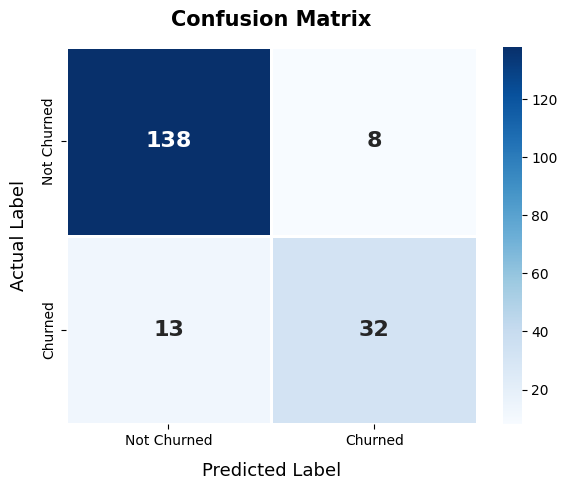

In [14]:
# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'size': 16, 'weight': 'bold'})

ax.set_xlabel('Predicted Label', fontsize=13, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=13, labelpad=10)
ax.set_title('Confusion Matrix', fontsize=15, fontweight='bold', pad=15)

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN) — Correctly predicted Not Churned: {tn}")
print(f"False Positives (FP) — Incorrectly predicted Churned  : {fp}")
print(f"False Negatives (FN) — Missed Churned customers       : {fn}")
print(f"True Positives  (TP) — Correctly predicted Churned    : {tp}")

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Classification Report ──
print("=" * 55)
print("            CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Not Churned (0)', 'Churned (1)']))

            CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Not Churned (0)       0.91      0.95      0.93       146
    Churned (1)       0.80      0.71      0.75        45

       accuracy                           0.89       191
      macro avg       0.86      0.83      0.84       191
   weighted avg       0.89      0.89      0.89       191



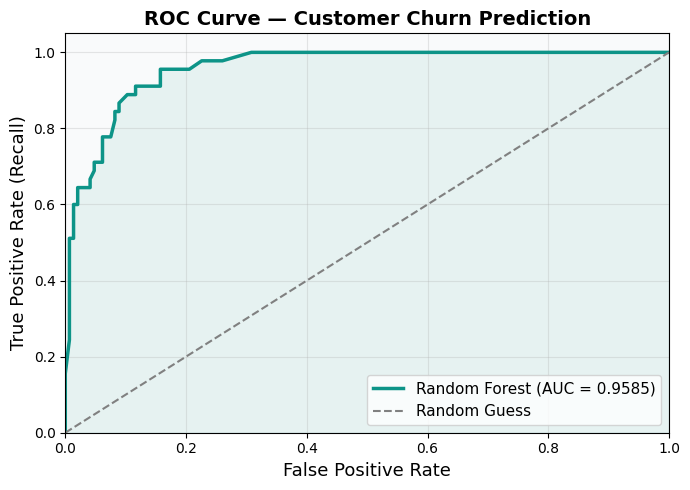

AUC Score: 0.9585  (1.0 = perfect, 0.5 = random)


In [16]:
# ── ROC Curve ──
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr, tpr, color='#0D9488', lw=2.5,
        label=f'Random Forest (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess')

ax.fill_between(fpr, tpr, alpha=0.08, color='#0D9488')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curve — Customer Churn Prediction', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_facecolor('#F9FAFB')

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC Score: {auc_score:.4f}  (1.0 = perfect, 0.5 = random)")

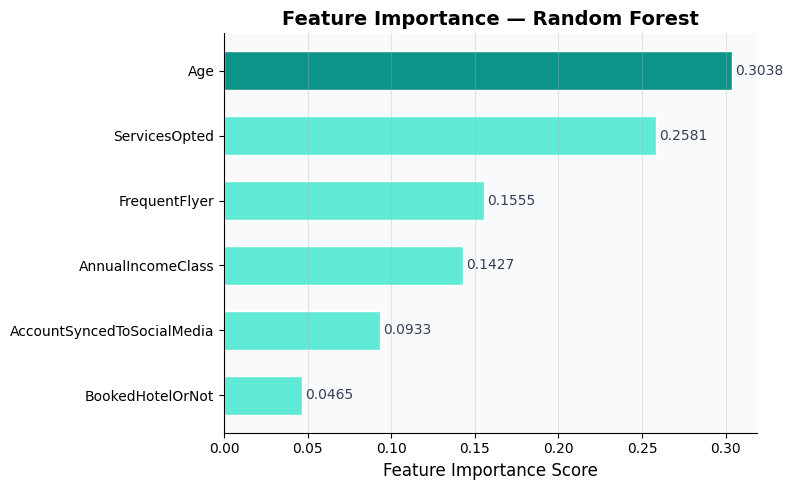


Feature Importance Ranking:
Age                           0.303845
ServicesOpted                 0.258088
FrequentFlyer                 0.155542
AnnualIncomeClass             0.142701
AccountSyncedToSocialMedia    0.093308
BookedHotelOrNot              0.046516


In [17]:
# ── Feature Importance Analysis ──
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#0D9488' if v == feature_importances.max() else '#5EEAD4'
          for v in feature_importances.values]

bars = ax.barh(feature_importances.index, feature_importances.values,
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, feature_importances.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, color='#334155')

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_facecolor('#F9FAFB')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importances.sort_values(ascending=False).to_string())

---
## 7. Visualizations

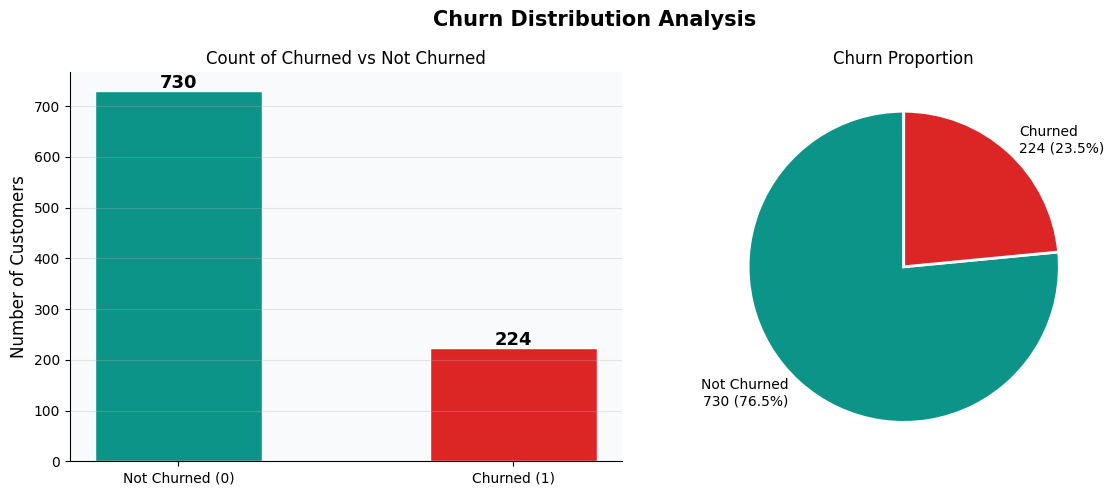

In [18]:
# ── 7.1 Churn Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Distribution Analysis', fontsize=15, fontweight='bold')

# Bar chart
counts = df['Target'].value_counts()
bars = axes[0].bar(['Not Churned (0)', 'Churned (1)'], counts.values,
                    color=['#0D9488', '#DC2626'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].set_title('Count of Churned vs Not Churned', fontsize=12)
axes[0].set_facecolor('#F9FAFB')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
labels = [f'Not Churned\n{counts[0]} ({counts[0]/len(df)*100:.1f}%)',
          f'Churned\n{counts[1]} ({counts[1]/len(df)*100:.1f}%)']
axes[1].pie(counts.values, labels=labels, colors=['#0D9488', '#DC2626'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=12)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

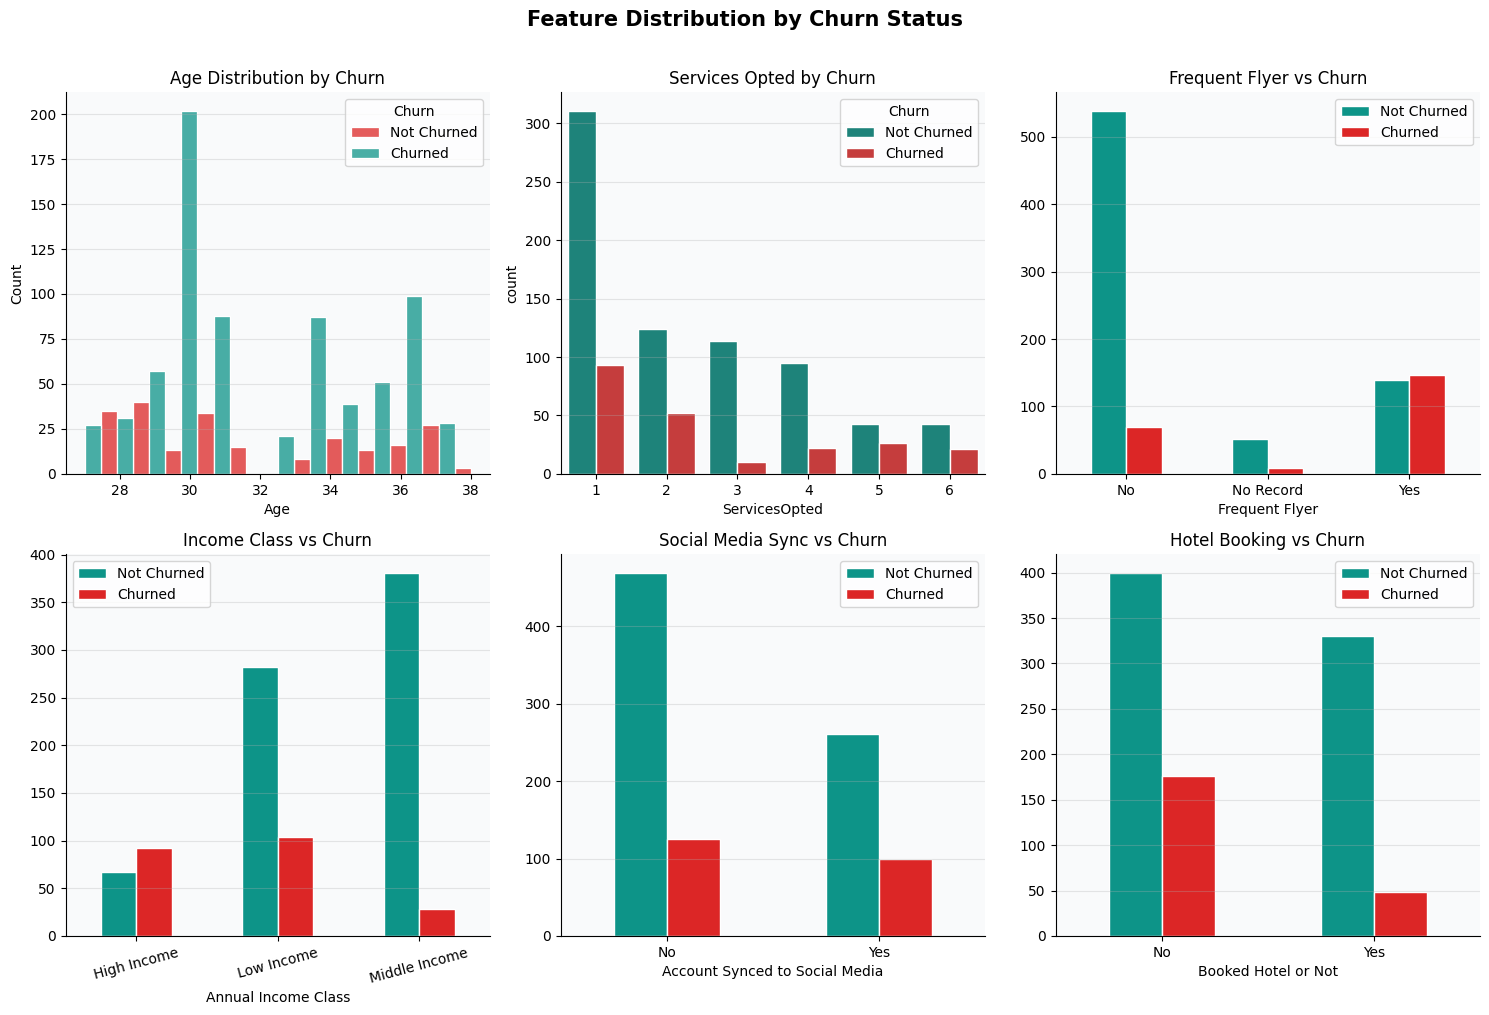

In [19]:
# ── 7.2 Key Feature Distributions by Churn Status ──
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distribution by Churn Status', fontsize=15, fontweight='bold', y=1.01)

palette = {0: '#0D9488', 1: '#DC2626'}

# Age distribution
sns.histplot(data=df, x='Age', hue='Target', multiple='dodge',
             palette=palette, bins=12, ax=axes[0, 0], edgecolor='white')
axes[0, 0].set_title('Age Distribution by Churn', fontsize=12)
axes[0, 0].legend(['Not Churned', 'Churned'], title='Churn')

# Services Opted
sns.countplot(data=df, x='ServicesOpted', hue='Target',
              palette=palette, ax=axes[0, 1], edgecolor='white')
axes[0, 1].set_title('Services Opted by Churn', fontsize=12)
axes[0, 1].legend(['Not Churned', 'Churned'], title='Churn')

# Frequent Flyer
ff_churn = df.groupby(['FrequentFlyer', 'Target']).size().unstack(fill_value=0)
ff_churn.plot(kind='bar', ax=axes[0, 2], color=['#0D9488', '#DC2626'],
              edgecolor='white', rot=0)
axes[0, 2].set_title('Frequent Flyer vs Churn', fontsize=12)
axes[0, 2].set_xlabel('Frequent Flyer')
axes[0, 2].legend(['Not Churned', 'Churned'])

# Annual Income Class
inc_churn = df.groupby(['AnnualIncomeClass', 'Target']).size().unstack(fill_value=0)
inc_churn.plot(kind='bar', ax=axes[1, 0], color=['#0D9488', '#DC2626'],
               edgecolor='white', rot=15)
axes[1, 0].set_title('Income Class vs Churn', fontsize=12)
axes[1, 0].set_xlabel('Annual Income Class')
axes[1, 0].legend(['Not Churned', 'Churned'])

# Account Synced to Social Media
social_churn = df.groupby(['AccountSyncedToSocialMedia', 'Target']).size().unstack(fill_value=0)
social_churn.plot(kind='bar', ax=axes[1, 1], color=['#0D9488', '#DC2626'],
                  edgecolor='white', rot=0)
axes[1, 1].set_title('Social Media Sync vs Churn', fontsize=12)
axes[1, 1].set_xlabel('Account Synced to Social Media')
axes[1, 1].legend(['Not Churned', 'Churned'])

# Booked Hotel
hotel_churn = df.groupby(['BookedHotelOrNot', 'Target']).size().unstack(fill_value=0)
hotel_churn.plot(kind='bar', ax=axes[1, 2], color=['#0D9488', '#DC2626'],
                 edgecolor='white', rot=0)
axes[1, 2].set_title('Hotel Booking vs Churn', fontsize=12)
axes[1, 2].set_xlabel('Booked Hotel or Not')
axes[1, 2].legend(['Not Churned', 'Churned'])

for ax in axes.flat:
    ax.set_facecolor('#F9FAFB')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

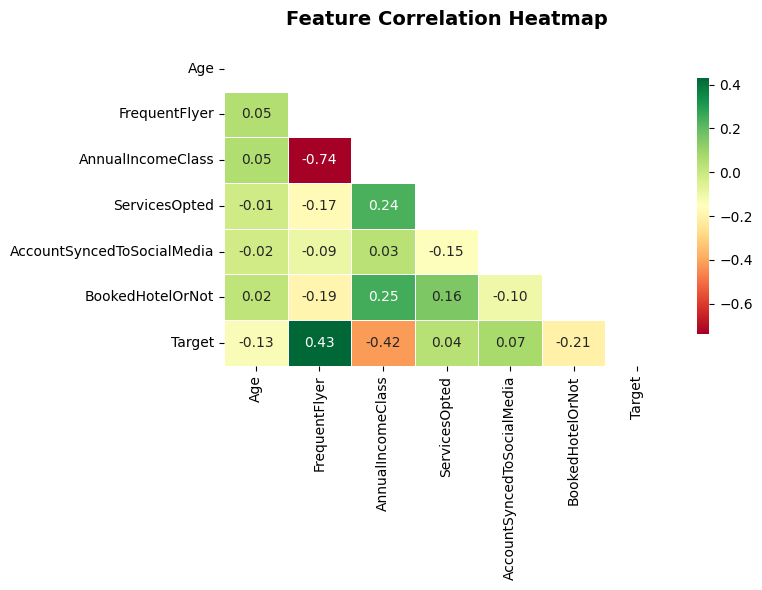

In [20]:
# ── 7.3 Correlation Heatmap (Processed Data) ──
fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = df_processed.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

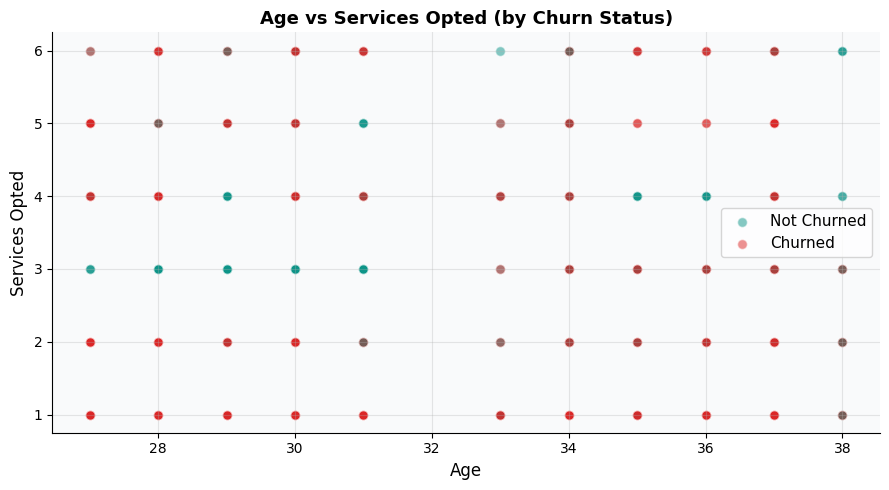

In [21]:
# ── 7.4 Age vs Services Opted — Scatter Plot by Churn ──
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, name in [(0, '#0D9488', 'Not Churned'), (1, '#DC2626', 'Churned')]:
    subset = df[df['Target'] == label]
    ax.scatter(subset['Age'], subset['ServicesOpted'],
               c=color, label=name, alpha=0.5, edgecolors='white', s=50)

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Services Opted', fontsize=12)
ax.set_title('Age vs Services Opted (by Churn Status)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_facecolor('#F9FAFB')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Conclusion

### Model Performance Summary

The **Random Forest Classifier** was successfully trained and evaluated on the Customer Travel Churn dataset. Key results:

| Metric | Value |
|--------|-------|
| Accuracy | 89.01% |
| ROC-AUC Score | 0.9585 |
| Training Samples | 763 |
| Testing Samples | 191 |

### Features Contributing Most to Churn

Based on the Feature Importance analysis:
1. **ServicesOpted** — The number of services a customer has opted for is the strongest predictor of churn. Customers with fewer services are more likely to churn.
2. **Age** — Age is a significant demographic factor; younger customers tend to churn more.
3. **FrequentFlyer** — Frequent flyers show higher loyalty and are less likely to churn.
4. **BookedHotelOrNot** — Customers who book hotels through the platform are more engaged.
5. **AnnualIncomeClass** — Income class has a moderate influence on churn behavior.
6. **AccountSyncedToSocialMedia** — Social media integration has the least predictive power.

### Key Insights
- The dataset is **imbalanced** (76.5% not churned vs 23.5% churned), yet Random Forest handled it well due to its ensemble nature.
- **Handling 'No Record'** in FrequentFlyer was an important cleaning step.
- The model is **deployed on Streamlit Cloud** for real-time predictions via a web interface.

### Possible Improvements & Future Enhancements
1. **Class Imbalance Handling**: Apply SMOTE (Synthetic Minority Oversampling Technique) or use class_weight='balanced' to further improve recall on churned customers.
2. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to optimize `n_estimators`, `max_depth`, `min_samples_split`.
3. **Advanced Algorithms**: Experiment with XGBoost, LightGBM, or CatBoost for potentially higher accuracy.
4. **Explainability**: Integrate SHAP (SHapley Additive exPlanations) for per-prediction feature explanation.
5. **Real-time Retraining**: Set up a pipeline to retrain the model periodically as new customer data arrives.
6. **Feature Engineering**: Create interaction features like `Age × ServicesOpted` or flag high-value customers.